In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, lognorm, pearsonr
from sklearn.metrics import r2_score

# Import data

In [ ]:
# Load both old and new error dataframes
df_errors_A = pd.read_csv('../../../data-storage/outputs/distribution/bootstrap_errors_A.csv').rename(columns={'sample_size': 'N'})
df_errors_B = pd.read_csv('../../../data-storage/outputs/distribution/bootstrap_errors_B.csv').rename(columns={'sample_size': 'N'})

# Append the both batches of errors into a single dataframe
df_errors = pd.concat([df_errors_A, df_errors_B], ignore_index=True)

del df_errors_A, df_errors_B


df_errors['M'] = df_errors['n_x'] * df_errors['n_y']

In [3]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# Study influences

In [5]:
sns.set(style="whitegrid")

## Weighted transition matrix and direct goal probabilities

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_4744\1756011749.py:34: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes,


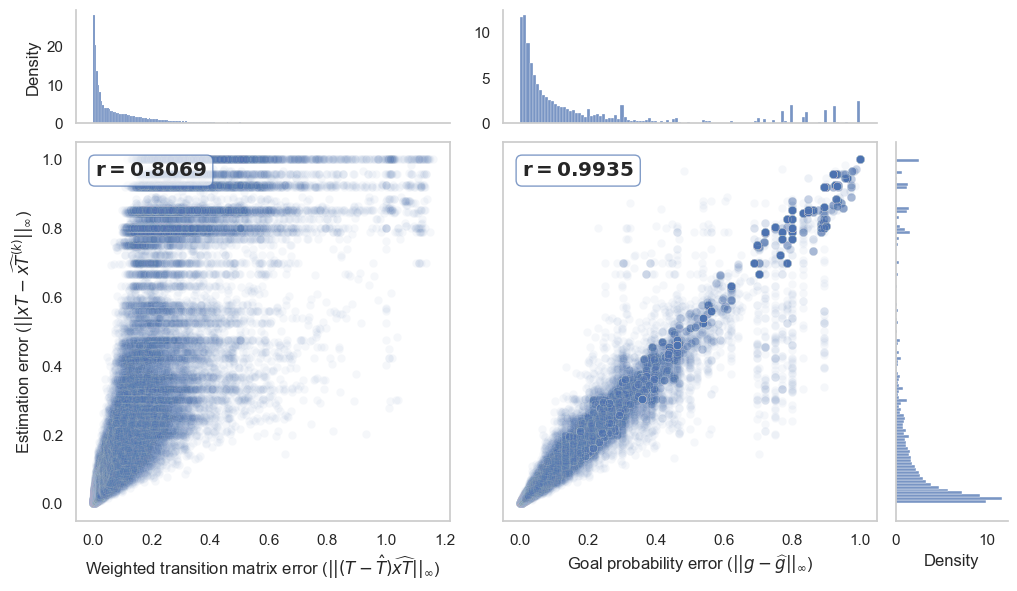

In [6]:
y_col = 'xT_error_inf_norm'
x_cols = [
    'weighted_transition_matrix_error_inf_norm',
    'g_error_inf_norm', 
    ]
y_label = r'Estimation error (${||xT-\widehat{xT}^{(k)}||_\infty}$)'
x_labels = [
    r'Weighted transition matrix error (${||(T-\hat{T})\widehat{xT}||_\infty}$)',
    r'Goal probability error (${||g-\widehat{g}||_\infty}$)', 
    ]

hist_size = 0.30

# sns.set(style="white") # Remove gridlines 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)


hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols+hist_size, 5*(1+hist_size)), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
        
    # Scatter plot 
    ax = axes[idx] 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.05) 
    ax.grid(False)
    
    pearson_corr, _ = pearsonr(x, y)
    ax.text( 0.05, 0.95, 
            f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor=hist_color)
            )

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Estimation error (${||xT-\widehat{xT}^{(k)}||_\infty}$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.30]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.set_ylabel('Density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)
    if idx > 0:
        ax_hist_above.set_ylabel('')

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        ax_hist = ax.inset_axes([1.05, 0, 0.30, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        ax_hist.set_xlabel('Density')
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
        ax_hist.grid(False) 
plt.tight_layout() 
plt.show()

## More quantities

In [10]:
y_col = 'xT_error_inf_norm'
x_cols = ['transition_matrix_error_inf_norm', 'weighted_transition_matrix_error_inf_norm',
                            'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm']
y_label = r'Estimation error ($||xT-\widehat{xT}^{(k)}||_\infty$)'
x_labels = [r'Transition matrix error ($||T-\widehat{T}||_\infty$)', 
            r'Weighted transition matrix error ($||(T-\hat{T})\widehat{xT}||_\infty$)',
            r'Goal probability error ($||g-\widehat{g}||_\infty$)', 
            r'Expected goals error ($||xG-\widehat{xG}||_\infty$)', 
            r'Shot probability error ($||p_{shot}-\widehat{p_{shot}}||_\infty$)',
            ]

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_4744\790601545.py:24: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes,


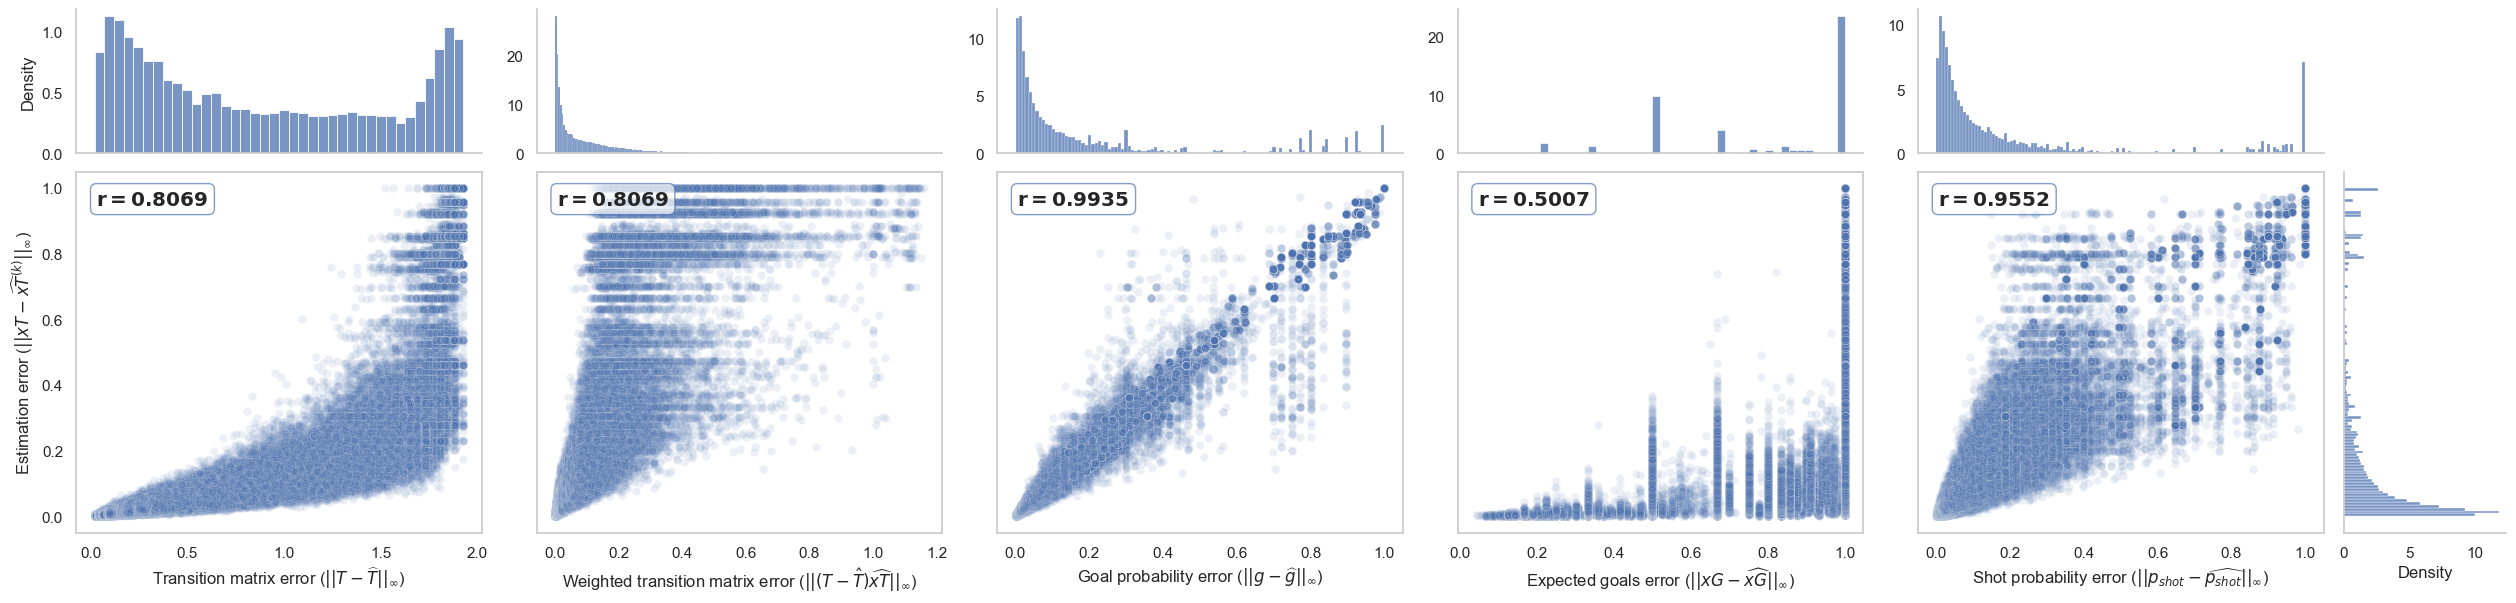

In [11]:
# sns.set(style="white") # Remove gridlines # Filter out the model error itself 
plot_columns = [col for col in x_cols if col != 'xT_error_inf_norm'] 
plot_labels = [label for col, label in zip(x_cols, x_labels) if col != 'xT_error_inf_norm'] 
n_cols = len(plot_columns)

# plot_columns.append('histogram') # Placeholder for histogram
# plot_labels.append('Histogram') # Placeholder label 

hist_color = sns.color_palette()[0]

fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 7), sharey=True) 
for idx, (col, label) in enumerate(zip(plot_columns, plot_labels)):
    x = df_errors[col].values 
    y = df_errors['xT_error_inf_norm'].values 
    
    
    # Scatter plot 
    ax = axes[idx] 
    sns.scatterplot(x=x, y=y, ax=ax, alpha=0.1) 
    ax.grid(False)
    
    pearson_corr, _ = pearsonr(x, y)
    ax.text( 0.05, 0.95, 
            f"$\mathbf{{r = {pearson_corr:.4f}}}$", transform=ax.transAxes, 
            ha='left', va='top', 
            fontsize='large', fontweight='extra bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor=hist_color)
            )

    # Axis labels 
    ax.set_xlabel(label) 
    if idx == 0: 
        ax.set_ylabel(r'Estimation error ($||xT-\widehat{xT}^{(k)}||_\infty$)') 
    else: ax.set_ylabel('') 

    # Add histogram above every scatterplot of the x-axis
    ax_hist_above = ax.inset_axes([0, 1.05, 1, 0.40]) # small axes on the top
    sns.histplot(x=x, bins='auto', orientation='horizontal', color=hist_color, ax=ax_hist_above, stat='density')
    ax_hist_above.grid(False)
    ax_hist_above.tick_params(bottom=False, labelbottom=False)
    if idx > 0:
        ax_hist_above.set_ylabel('')
    ax_hist_above.spines['right'].set_visible(False)
    ax_hist_above.spines['top'].set_visible(False)

    # Add histogram on the right **only for the last subplot** 
    if idx == n_cols - 1: 
        # print("We zijn er") 
        # ax_hist = axes[idx] 
        ax_hist = ax.inset_axes([1.05, 0, 0.40, 1]) # small axes on the right 
        sns.histplot(y=y, bins='auto', orientation='vertical', color=hist_color, ax=ax_hist, stat='density') 
        # ax_hist.set_xlabel('') 
        # ax_hist.set_ylabel('') 
        # ax_hist.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False) 
        ax_hist.tick_params(left=False, labelleft=False)
        ax_hist.grid(False) 
        ax_hist.spines['right'].set_visible(False)
        ax_hist.spines['top'].set_visible(False)
plt.tight_layout() 
plt.show()